In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../sample_data/credit_scoring_dataset.csv")

In [6]:
# Features and target
X = df[['age', 'gender', 'marital_status', 'employment_status',
        'length_of_employment_years', 'monthly_net_income',
        'number_of_credit_cards', 'previous_defaults', 'credit_amount',
        'loan_duration_months', 's_score']]
y = df['default']

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [8]:
# Define preprocessing for categorical features
categorical_cols = ['gender', 'marital_status', 'employment_status']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ], remainder='passthrough'  # Keep other columns unchanged
)

In [9]:
# Build the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

In [10]:
# Train the model using the pipeline
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [11]:
# Predictions
y_pred = pipeline.predict(X_test)

In [12]:
# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.95

Confusion Matrix:
[[7598   46]
 [ 374  982]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      7644
           1       0.96      0.72      0.82      1356

    accuracy                           0.95      9000
   macro avg       0.95      0.86      0.90      9000
weighted avg       0.95      0.95      0.95      9000



# AUC and ROC Curve

In [11]:
# To draw the AUC (Area Under the Curve) for the credit scoring model,
# we can use the predict_proba method, which returns the predicted probabilities for each class ("default" and "no default").
# AUC is calculated from the Receiver Operating Characteristic (ROC) curve,
# which compares the true positive rate (sensitivity) to the false positive rate (1 - specificity).

In [13]:
sns.set(style='darkgrid')

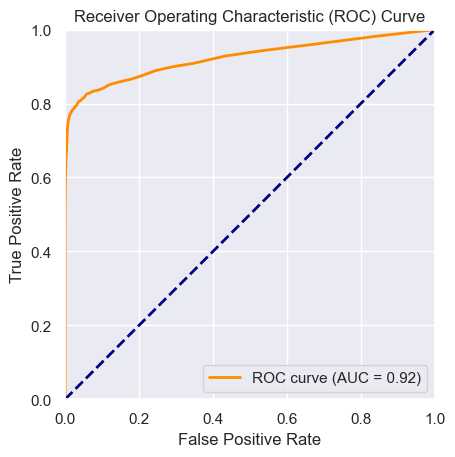

In [17]:
# Predict probabilities for the positive class (default = 1)
y_prob = pipeline.predict_proba(X_test)[:, 1]  # probability of default (class 1)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.gca().set_aspect('equal', 'box')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [15]:
# Optionally, print the AUC value
print(f'AUC: {roc_auc:.2f}')

AUC: 0.92


In [15]:
# Here's how AUC helps:

# True Positive Rate (TPR):
# The proportion of actual defaults that are correctly predicted by the model.
# False Positive Rate (FPR):
# The proportion of non-defaults that are incorrectly predicted as defaults by the model.

# AUC represents the likelihood that the model will rank
# a randomly chosen default instance higher than a randomly chosen non-default instance.

# AUC ranges from 0 to 1:

# AUC = 0.5:
# This is the performance of a random classifier, 
# meaning the model has no discrimination power between defaults and non-defaults.

# UC = 1:
# This represents a perfect model that correctly distinguishes all defaults from non-defaults.

# AUC < 0.5:
# The model is performing worse than random, suggesting it is predicting the default and non-default classes incorrectly.

# A higher AUC indicates that the model is good at distinguishing between customers who will default and those who won't.

In [16]:
# AUC is essentially a measure of how well the model 
# is able to distinguish between positive (default) and negative (non-default) cases,
# based on its predicted probabilities.
# The higher the AUC, the better the model's ability to rank defaults higher than non-defaults.

In [17]:
# Save the model with joblib
joblib.dump(pipeline, 'rf_model.joblib')

['rf_model.joblib']

In [18]:
# Save the DataFrames/Series as a dictionary
data = {'X_test': X_test, 'y_test': y_test}

# Save to a joblib file
joblib.dump(data, 'data.joblib')

['data.joblib']